In [42]:
from typing import Literal

from langchain_groq import ChatGroq
from langchain_core.messages import (
    SystemMessage,
    HumanMessage,
    AIMessage,
    RemoveMessage
)

from langgraph.graph import (
    StateGraph,
    MessagesState,
    START,
    END
)

from langgraph.checkpoint.memory import InMemorySaver
from langgraph.graph.message import REMOVE_ALL_MESSAGES
from dotenv import load_dotenv


In [43]:
load_dotenv

llm = ChatGroq(
    model="openai/gpt-oss-20b",
    temperature=0
)


In [4]:
def chat(state: MessagesState):
    response = llm.invoke(state['messages'])

    return{
        'messages': [response]
    }

In [6]:
## when to summarize

def should_summarize(state: MessagesState)->Literal['summarize',END]:
    msessages = state['messages']
    if len(msessages) >6:
        return 'summarize'
    else:
        return END

In [ ]:
def summarize(state: MessagesState):

    messages = state["messages"]

    summary_prompt = [
        SystemMessage(
            content="""
Summarize the conversation briefly.

Return ONLY the actual summary.
Do NOT write "Conversation Summary" or any heading.

Keep:
- important facts
- user preferences
- project information
- important decisions
- requirements

Remove unnecessary details.
"""
        )
    ] + messages

    response = llm.invoke(summary_prompt)

    summary = response.content

    # Keep only recent 1 messages
    recent_messages = messages[-1:]

    # Remove all old messages
    delete_all = RemoveMessage(
        id=REMOVE_ALL_MESSAGES
    )

    return {
        "messages": [
            delete_all,

            SystemMessage(
                content=f"Conversation Summary:\n{summary}"
            ),

            *recent_messages
        ]
    }

In [39]:
## graph 

builder = StateGraph(MessagesState)


builder.add_node('chat',chat)
builder.add_node('summarize',summarize)


builder.add_edge(START,'chat')
builder.add_conditional_edges('chat',should_summarize)

builder.add_edge('summarize',END)






In [40]:
## checkpointers
checkpointer = InMemorySaver()

graph = builder.compile(checkpointer = checkpointer)

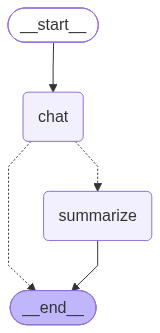

In [21]:
graph

In [41]:
## thread id
config = {
    "configurable": {
        "thread_id": "conversation_1"
    }
}

while True:
    user_input = input("\nHuman: ")

    if user_input.lower() in ["exit", "quit"]:
        print("chat ended")
        break

    result = graph.invoke(
        {
            "messages": [
                HumanMessage(content=user_input)
            ]
        },
        config
    )

    print("\nHuman:", user_input)

    print("AI:", result["messages"][-1].content)

    ## current messages in memory
    print(
        "\nCurrent messages in memory:",
        len(result["messages"])
    )

    ## show summary of old chats
    for message in result["messages"]:

        if (
            isinstance(message, SystemMessage)
            and message.content.startswith("Conversation Summary:")
        ):
            print("\n--- SUMMARY ---")
            print(message.content)
            print("----------------")


Human: my name is khan
AI: Nice to meet you, Khan! How can I help you today?

Current messages in memory: 2

Human: what  is my name
AI: Your name is Khan.

Current messages in memory: 4

Human: what is rag in one line 
AI: RAG (Retrieval‑Augmented Generation) is a language‑model technique that combines a generative model with an external knowledge retriever, so the model can fetch relevant documents on‑the‑fly and incorporate that information into its responses.

Current messages in memory: 6

Human: what is langsmith in one line 
AI: LangSmith is a platform for building, testing, and monitoring LLM‑powered applications, offering tools for data labeling, prompt management, and end‑to‑end observability.

Current messages in memory: 2

--- SUMMARY ---
Conversation Summary:
User introduced themselves as Khan, asked for confirmation of their name, and requested one‑line definitions of RAG (Retrieval‑Augmented Generation) and LangSmith.
----------------
chat ended
